# 필요한 자바 SDK 설치

윈도우 파워쉘에서 다음과 같이 실행

winget install --id Microsoft.OpenJDK.25

In [1]:
!python -m pip install konlpy wordcloud matplotlib numpy

  Using cached konlpy-0.6.0-py2.py3-none-any.whl.metadata (1.9 kB)
  Using cached wordcloud-1.9.6-cp314-cp314-win_amd64.whl.metadata (3.5 kB)
  Using cached matplotlib-3.11.0-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached jpype1-1.7.1-cp314-cp314-win_amd64.whl.metadata (4.3 kB)
  Using cached lxml-6.1.1-cp314-cp314-win_amd64.whl.metadata (3.6 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached konlpy-0.6.0-py2.py3-none-any.whl (19.4 MB)
Using cached wordcloud-1.9.6-cp314-cp314-win_amd64.whl (308 kB)
Using cached matplotlib-3.11.0-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached contourpy-

In [2]:
!python -m pip install tqdm

  Using cached tqdm-4.68.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.68.3-py3-none-any.whl (78 kB)


# Tokenizer - Okt

In [3]:
from collections import Counter
from konlpy.tag import Okt

import os
os.environ['JAVA_HOME'] = r'C:\Program Files\Microsoft\jdk-25.0.3.9-hotspot'

# 테스트용 한국어 텍스트 데이터 준비
sample_text = """
파이썬은 데이터 분석과 인공지능 분야에서 가장 인기 있는 프로그래밍 언어입니다.
파이썬의 라이브러리인 KoNLPy를 사용하면 한국어 자연어 처리를 쉽게 할 수 있습니다.
자연어 처리에서 가장 기본이 되는 실습은 단어의 빈도수를 세는 워드카운트입니다.
워드카운트를 통해 텍스트 데이터에서 어떤 단어가 가장 중요하게 등장하는지 분석할 수 있습니다.
컴퓨터가 한국어 조사를 잘 분리해야 정확한 데이터 분석이 가능해집니다.
"""

# KoNLPy 의 Okt 형태소 분석기 초기화
okt = Okt()

# 텍스트에서 명사만 추출하기
noun_list = okt.nouns(sample_text)

print('========== 명사 목록 ==========')
print(f'총 명사 개수: {len(noun_list)} 개')
print(noun_list[:15], '... (생략)\n')

========== 명사 목록 ==========
총 명사 개수: 44 개
['파이썬', '데이터', '분석', '인공', '지능', '분야', '가장', '인기', '프로그래밍', '언어', '파이썬', '라이브러리', '를', '사용', '한국어'] ... (생략)



In [4]:
# 단어 빈도수 계산 (파이썬 내장 Counter 사용)
word_counts = Counter(noun_list)

# 가장 많이 등장한 상위 5개 단어 출력
print('========== 워드 카운트 결과 (상위 5개) ==========')
top_words = word_counts.most_common(5)
for word, count in top_words:
    print(f'[{word}] : {count} 회')

========== 워드 카운트 결과 (상위 5개) ==========
[데이터] : 3 회
[분석] : 3 회
[가장] : 3 회
[파이썬] : 2 회
[한국어] : 2 회


In [5]:
print('========== 의미있는 두 글자 이상 단어 (상위 5개) ==========')
filtered_counts = Counter([noun for noun in noun_list if len(noun) > 1])
top_words_filtered = filtered_counts.most_common(5)
for word, count in top_words_filtered:
    print(f'[{word}] : {count} 회')

========== 의미있는 두 글자 이상 단어 (상위 5개) ==========
[데이터] : 3 회
[분석] : 3 회
[가장] : 3 회
[파이썬] : 2 회
[한국어] : 2 회


In [6]:
print(len(word_counts))
print(len(filtered_counts))

30
27


In [7]:
word_counts

Counter({'데이터': 3,
         '분석': 3,
         '가장': 3,
         '파이썬': 2,
         '한국어': 2,
         '자연어': 2,
         '처리': 2,
         '수': 2,
         '단어': 2,
         '워드': 2,
         '카운트': 2,
         '인공': 1,
         '지능': 1,
         '분야': 1,
         '인기': 1,
         '프로그래밍': 1,
         '언어': 1,
         '라이브러리': 1,
         '를': 1,
         '사용': 1,
         '기본': 1,
         '실습': 1,
         '빈': 1,
         '도수': 1,
         '통해': 1,
         '텍스트': 1,
         '등장': 1,
         '컴퓨터': 1,
         '조사': 1,
         '분리': 1})

## Word Cloud

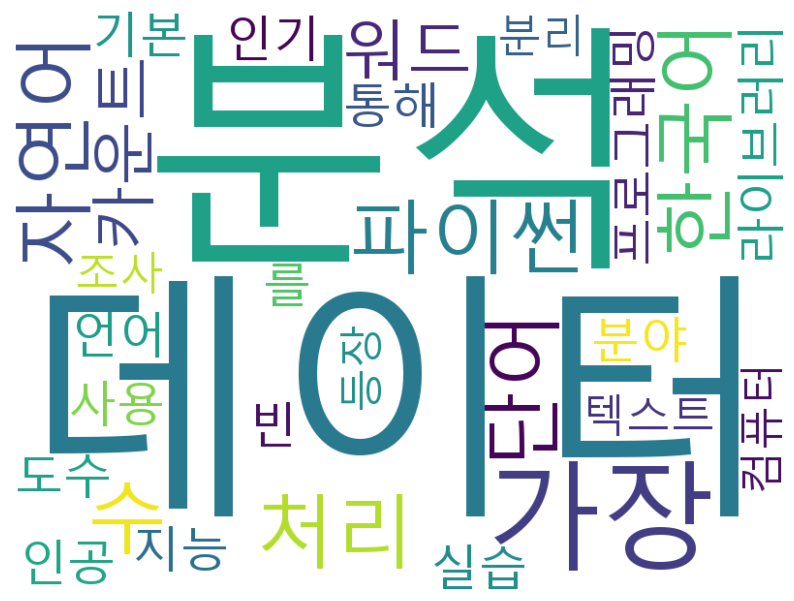

In [8]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Matplotlib 을 위한 한글 설정 (차트 제목, 축 텍스트 용)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False) # 마이너스 기호 깨짐 방지

# WordCloud 를 위한 폰트 경로 설정 (이미지 자체에 표시되기 위한 폰트)
font_path = r'C:\Windows\Fonts\malgun.ttf'
wc = WordCloud(
    font_path=font_path,
    background_color='white', # 배경색 (기본값은 검은색)
    width=800,
    height=600,
    max_words=100, # 최대 표시할 단어 수
    colormap='viridis', # 글자 색상 테마 (matplotlib colormap 참조)
)

# 빈도수 기반으로 워드 클라우드 생성
cloud = wc.generate_from_frequencies(word_counts)

# Matplotlib 를 사용해 화면에 출력
plt.figure(figsize=(10, 8))
plt.imshow(cloud, interpolation='bilinear')
plt.axis('off') # 축 눈금 숨기기
plt.show()

In [9]:
# 이미지 파일을 저장하려면 다음과 같이 호출
cloud.to_file('../img/wordcloud_result.png')

# Tokenizer - kcBERT

In [10]:
!python -m pip install transformers torch

  Using cached pyyaml-6.0.3-cp314-cp314-win_amd64.whl.metadata (2.4 kB)
  Using cached regex-2026.5.9-cp314-cp314-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached click-8.4.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached anyio-4.14.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Usi

In [11]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('beomi/kcbert-base')
tokens1 = tokenizer.tokenize(sample_text)
print(tokens1)

['파', '##이', '##썬', '##은', '데이터', '분석', '##과', '인공', '##지능', '분야', '##에서', '가장', '인기', '있는', '프로', '##그래', '##밍', '언어', '##입니다', '.', '파', '##이', '##썬', '##의', '라이', '##브', '##러', '##리', '##인', 'K', '##o', '##N', '##L', '##P', '##y', '##를', '사용', '##하면', '한국', '##어', '자연', '##어', '처리', '##를', '쉽게', '할', '수', '있습니다', '.', '자연', '##어', '처리', '##에서', '가장', '기본이', '되는', '실', '##습', '##은', '단어', '##의', '빈', '##도', '##수를', '세', '##는', '워', '##드', '##카', '##운', '##트', '##입니다', '.', '워', '##드', '##카', '##운', '##트를', '통해', '텍', '##스트', '데이터', '##에서', '어떤', '단어가', '가장', '중요', '##하게', '등장', '##하는지', '분석', '##할', '수', '있습니다', '.', '컴퓨터', '##가', '한국', '##어', '조사를', '잘', '분리', '##해야', '정확한', '데이터', '분석', '##이', '가능', '##해', '##집니다', '.']


In [12]:
token1_ids = tokenizer.convert_tokens_to_ids(tokens1)
print(token1_ids)

[3231, 4017, 5184, 4057, 17980, 14481, 4128, 14583, 25061, 16029, 7971, 8547, 12764, 8032, 10419, 9791, 4940, 18010, 8074, 17, 3231, 4017, 5184, 4042, 17564, 4408, 4053, 4038, 4118, 44, 4404, 4581, 4450, 4579, 4399, 4180, 9021, 7986, 7997, 4071, 10459, 4071, 9810, 4180, 9955, 3358, 1931, 8982, 17, 10459, 4071, 9810, 7971, 8547, 21152, 8511, 2009, 4528, 4057, 10610, 4042, 1667, 4029, 9405, 1862, 4008, 2376, 4273, 4024, 4202, 4104, 8074, 17, 2376, 4273, 4024, 4202, 19143, 11258, 3145, 8795, 17980, 7971, 8374, 20764, 8547, 8539, 8007, 15484, 9188, 14481, 4082, 1931, 8982, 17, 15513, 4009, 7997, 4071, 15576, 2483, 13331, 8021, 13432, 17980, 14481, 4017, 8545, 4032, 12152, 17]


In [13]:
meaningful_words = []

# 워드 카운트를 위한 필터링 전처리
for token in tokens1:
    # 조사나 어미 앞에 '##' 을 붙인다.
    # '##' 으로 시작하지 않는 토큰이 원래 단어의 핵심(명사/어근) 부분이다. 
    if not token.startswith('##'):
        # 특수 문자나 한 글자짜리 조사(의, 에 등...)를 걸러내기 위해 2글자 이상만 추출
        if len(token) > 1:
            meaningful_words.append(token)

# 빈도수 계산
word_counts = Counter(meaningful_words)
word_counts_top = word_counts.most_common(5)

for word, count in word_counts_top:
    print(f'{word} : {count} 회')

데이터 : 3 회
분석 : 3 회
가장 : 3 회
한국 : 2 회
자연 : 2 회


## Word Cloud

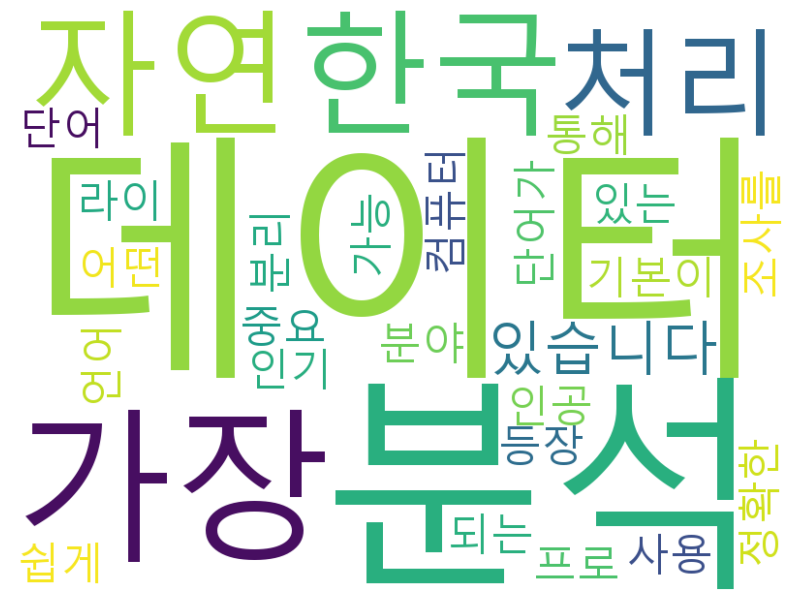

In [14]:
# 빈도수 기반으로 워드 클라우드 생성
cloud2 = wc.generate_from_frequencies(word_counts)

plt.figure(figsize=(10, 8))
plt.imshow(cloud2, interpolation='bilinear')
plt.axis('off') # 축 눈금 숨기기
plt.show()

# Tokenizer - KLUE RoBERTa

In [15]:
tokenizer2 = AutoTokenizer.from_pretrained('klue/roberta-base')
tokens2 = tokenizer2.tokenize(sample_text)
print(tokens2)

['파이', '##썬', '##은', '데이터', '분석', '##과', '인공지능', '분야', '##에서', '가장', '인기', '있', '##는', '프로그래밍', '언어', '##입니다', '.', '파이', '##썬', '##의', '라이브', '##러리', '##인', 'K', '##o', '##N', '##L', '##P', '##y', '##를', '사용', '##하면', '한국어', '자연', '##어', '처리', '##를', '쉽', '##게', '할', '수', '있', '##습', '##니다', '.', '자연', '##어', '처리', '##에서', '가장', '기본', '##이', '되', '##는', '실습', '##은', '단어', '##의', '빈도', '##수', '##를', '세', '##는', '워드', '##카운트', '##입니다', '.', '워드', '##카운트', '##를', '통해', '텍스트', '데이터', '##에서', '어떤', '단어', '##가', '가장', '중요', '##하', '##게', '등장', '##하', '##는지', '분석', '##할', '수', '있', '##습', '##니다', '.', '컴퓨터', '##가', '한국어', '조사', '##를', '잘', '분리', '##해야', '정확', '##한', '데이터', '분석', '##이', '가능', '##해', '##집니다', '.']


In [16]:
meaningful_words2 = []

# 워드 카운트를 위한 필터링 전처리
for token in tokens2:
    # 조사나 어미 앞에 '##' 을 붙인다.
    # '##' 으로 시작하지 않는 토큰이 원래 단어의 핵심(명사/어근) 부분이다. 
    if not token.startswith('##'):
        # 특수 문자나 한 글자짜리 조사(의, 에 등...)를 걸러내기 위해 2글자 이상만 추출
        if len(token) > 1:
            meaningful_words2.append(token)

# 빈도수 계산
word_counts2 = Counter(meaningful_words2)
word_counts_top2 = word_counts2.most_common(5)

for word, count in word_counts_top2:
    print(f'{word} : {count} 회')

데이터 : 3 회
분석 : 3 회
가장 : 3 회
파이 : 2 회
한국어 : 2 회


## Word Cloud

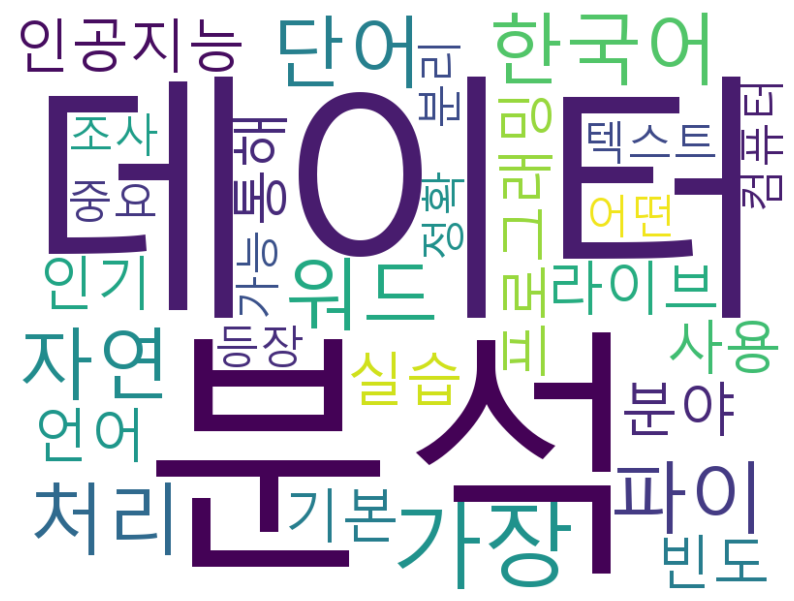

In [17]:
# 빈도수 기반으로 워드 클라우드 생성
cloud3 = wc.generate_from_frequencies(word_counts2)

plt.figure(figsize=(10, 8))
plt.imshow(cloud3, interpolation='bilinear')
plt.axis('off') # 축 눈금 숨기기
plt.show()